In [29]:
import numpy as np
from itertools import chain

from response_stats.generators import PoissonSpikeGenerator
from response_stats.responses import ResponseConfig, make_response_data, ResponseDetector
from response_stats.responses.response_tests import WilcoxonTest, SurrogateTest

from response_stats.plot_utils import *

In [ ]:
from scipy.stats import beta

from response_stats.config import default_seed
class PoissonSpikeGenerator:
    def __init__(self, baseline_fr, response_fr, 
                 latency, duration, dt, baseline_T, stimulus_T, 
                 induce_refractory_period=False, kappa=4, a=None, b=None, rng=None):
        
        self.baseline_fr = baseline_fr
        self.response_fr = response_fr
        self.latency = latency
        self.duration = duration
        self.dt = dt
        self.baseline_T = baseline_T
        self.stimulus_T = stimulus_T
    
        self.total_bins = int((baseline_T + stimulus_T) / dt)

        self.induce_refractory_period = induce_refractory_period
        self.kappa = kappa

        self.a = a
        self.b = b

        if induce_refractory_period:
            self._initialize_burn_in()

        self.r_t = self._build_rate_function(self.total_bins, self.baseline_T)
        
        if rng is None: 
            self.rng = np.random.default_rng(default_seed)
        else:
            self.rng = rng

    def _force_renewal_process(self, spike_train):
        """
        Induce a refractory period by removing every k-th spike.
        This will results in a spike train with ISIs following a gamma pdf.
        """
        kappa = self.kappa
        if spike_train.size == 0:
            return spike_train
        keep = np.arange(kappa-1, spike_train.size, kappa)
        return spike_train[keep]
    
    def _burn_in_period(self):
        burn_in = round(self.kappa / self.baseline_fr, 3)
        #print(burn_in)
        # if burn_in < 0.5:
        #     burn_in = 0.5
        return burn_in
    
    def _initialize_burn_in(self):
        # adjust FR to account for thinning process
        self.baseline_fr = self.baseline_fr * self.kappa
        self.response_fr = self.response_fr * self.kappa

        self.burn_in_period = self._burn_in_period()
        self.burn_in_baseline_T = self.baseline_T + self.burn_in_period
        self.burn_in_total_bins = int((self.burn_in_period + self.baseline_T + self.stimulus_T) / self.dt)
        self.burn_in_r_t = self._build_rate_function(self.burn_in_total_bins, self.burn_in_baseline_T)

        # return original FR values, mainly for plotting text
        self.baseline_fr = self.baseline_fr / self.kappa
        self.response_fr = self.response_fr / self.kappa

    def _build_rate_function(self, total_bins, baseline_T):
        # set the baseline fr for all bins
        r_t = np.full(total_bins, float(self.baseline_fr))

        # overwrite the response period with the response FR
        response_onset = int(self.latency / self.dt) + int(baseline_T / self.dt)
        response_offset = int((self.latency / self.dt) + int(self.duration / self.dt)) + int(baseline_T / self.dt) 

        if self.a and self.b:
            x_ = np.linspace(0, 1, response_offset - response_onset)
            r_ = beta.pdf(x_, self.a, self.b)

            fr_response = self.response_fr - self.baseline_fr
            r_r = r_ * fr_response / np.max(r_) +  self.baseline_fr

            try:
                r_t[response_onset:response_offset] = r_r
            except ValueError:
                print(f"stimulus time ({self.stimulus_T}) can't accomodate the response duration ({self.duration}) and latency ({self.latency}).")
                sys.exit(1)

        else:       
            r_t[response_onset:response_offset] = self.response_fr

        ## placeholder: add bursts. 

        return r_t

    def _remove_burn_in_period(self, spike_times):
        spike_times = spike_times[spike_times > self.burn_in_period]
        spike_times = spike_times - self.burn_in_period
        return spike_times

    def generate(self, n_trials: int = 1, squeeze: bool = True):
        """
        Generate Poisson spike trains.

        Parameters
        ----------
        n_trials : int, default=1
            Number of trials to generate.
        squeeze : bool, default=True
            If True and n_trials==1, return a single 1D numpy array.
            Otherwise, return a list of 1D numpy arrays.

        Returns
        -------
        spikes : np.ndarray or list[np.ndarray]
            Spike times (seconds). 1D array if squeeze and n_trials==1, else list.
        """
        dt = self.dt

        ## handle rate function
        if self.induce_refractory_period:
            total_bins = self.burn_in_total_bins
            r_t = self.burn_in_r_t
        else:
            total_bins = self.total_bins
            r_t = self.r_t
        
        p = r_t * dt # prob of a spike in each time bin as a function of the time-varying rate

        if n_trials == 1:

            hits = self.rng.random(total_bins) <= p
            idx = np.flatnonzero(hits)
            spike_times = idx.astype(float) * dt
            if self.induce_refractory_period:
                spike_times = self._force_renewal_process(spike_times)
                spike_times = self._remove_burn_in_period(spike_times)

            return spike_times if squeeze else [spike_times]

        hits = self.rng.random(size=(n_trials, total_bins)) <= p
        trials: list[np.ndarray] = []
        for i in range(n_trials):
            
            idx = np.flatnonzero(hits[i])
            spike_times = idx.astype(float) * dt

            if self.induce_refractory_period:
                spike_times = self._force_renewal_process(spike_times)
                spike_times = self._remove_burn_in_period(spike_times)
                
            trials.append(spike_times)

        return trials

In [ ]:
from scipy.stats import poisson


rate_center = 0.01
n = 10
r = 0.5

r_t = generator.r_t
rate_centers = np.flatnonzero(generator.rng.random(size=(len(r_t))) <= rate_center)
n_spikes_per_burst = poisson.rvs(n, size=len(rate_centers))
spike_locations = [generator.rng.normal(loc=0, scale=r, size=n) for n in n_spikes_per_burst] # get spike locations relative to the center of the burst
bursts = np.concatenate([rate_centers[i] + s_l for i, s_l in enumerate(spike_locations)], dtype=object)

In [162]:
bursts / 1000

array([0.055563095156318604, 0.05470963337210339, 0.0542278135165176,
       0.05535424262077631, 0.056436053577779595, 0.05500041448317885,
       0.05474652007001877, 0.05548786176134416, 0.054172765012146795,
       0.05500884423921359, 0.05561688472084556, 0.05523542992326689,
       0.05496990207174614, 0.05580035227363144, 0.054924632905877596,
       0.05420964781169334, 0.0557655558481712, 0.06844368501568865,
       0.06760048915482943, 0.06852236620348072, 0.06762194141756621,
       0.06866361225036297, 0.06722815403736289, 0.06803883316014914,
       0.06814302201746454, 0.06816745879175316, 0.06789749140151484,
       0.06717993330817391, 0.06777632774033157, 0.06854654140735524,
       0.2211630801662448, 0.22038215047753645, 0.220797726251503,
       0.22122868747451438, 0.21992289038795024, 0.2208106383746642,
       0.22131471068109407, 0.22172299412851554, 0.2207997795979488,
       0.5520714396792807, 0.551626317805294, 0.5518215064369356,
       0.5518209036071929, 

In [415]:
sum(generator.rng.random(size=(len(r_t))) <= 0.001)

np.int64(5)

In [440]:
n_trials = 10
rate_center = 0.001

dt = generator.dt

## handle rate function
if generator.induce_refractory_period:
    total_bins = generator.burn_in_total_bins
    r_t = generator.burn_in_r_t
else:
    total_bins = generator.total_bins
    r_t = generator.r_t

p = r_t * dt # prob of a spike in each time bin as a function of the time-varying rate


hits = generator.rng.random(size=(n_trials, total_bins)) <= p
trials: list[np.ndarray] = []
bursts: list[np.ndarray] = []
for i in range(n_trials):
    
    idx = np.flatnonzero(hits[i])
    spike_times = idx.astype(float) * dt
    #############

    rate_centers = np.flatnonzero(generator.rng.random(size=(len(r_t))) <= rate_center) * dt # draw the number of bursts and their centers/locations
    print(rate_centers)
    n = generator.rng.uniform(2, 5, len(rate_centers))  # generate the value for the number of spikes per burst
    r = generator.rng.uniform(0.009, 0.2, len(rate_centers)) # generate the value for the range of the spike positions

    n_spikes_per_burst = poisson.rvs(n)
    if type(n_spikes_per_burst) == int:
        n_spikes_per_burst = [n_spikes_per_burst]
    print(n_spikes_per_burst)
    spike_locations = [generator.rng.uniform(low=-1*r[i], high=r[i], size=n) for i, n in enumerate(n_spikes_per_burst)] # get spike locations relative to the center of the burst
    if len(spike_locations):
        b = np.concatenate([rate_centers[i] + s_l for i, s_l in enumerate(spike_locations)], dtype=float)
        bursts.append(b)
    ##############
    #spike_times = np.sort(np.concatenate([b, spike_times]))

    if generator.induce_refractory_period:

        spike_times = generator._force_renewal_process(spike_times)
        spike_times = generator._remove_burn_in_period(spike_times)
    
    spike_times = np.sort(np.concatenate([b, spike_times]))

    trials.append(spike_times)


[0.128 1.018 1.592 2.065 2.087]
[3 4 2 5 6]
[1.013]
[6]
[0.299 0.799 0.884 1.038 1.16  1.271]
[4 2 3 5 2 4]
[0.419 1.403 1.776]
[4 1 2]
[]
[]
[0.387 1.467 1.861]
[2 5 1]
[]
[]
[0.277 1.665]
[3 1]
[]
[]
[0.628 1.505 1.924 2.098]
[2 3 5 5]


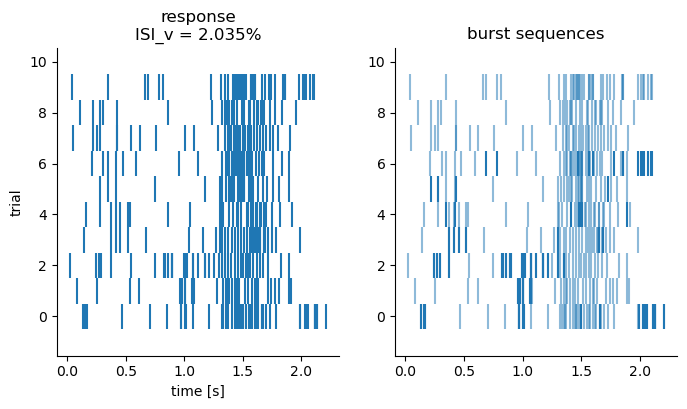

In [445]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].eventplot(trials)
ax[1].eventplot(trials, alpha=0.5)
ax[1].eventplot(bursts)

ax[0].set_xlabel("time [s]")
ax[0].set_ylabel("trial")

isi_V = sum(np.concatenate([np.diff(t) for t in trials]) < 0.001) / len(np.concatenate([np.diff(t) for t in trials])) * 100

ax[0].set_title(f"response\nISI_v = {round(isi_V, 3)}%")
ax[1].set_title("burst sequences")

sns.despine()
plt.show()

In [443]:
sum(np.concatenate([np.diff(t) for t in trials]) < 0.001) / len(np.concatenate([np.diff(t) for t in trials])) * 100

np.float64(2.0348837209302326)

Baseline duration: 1 s
Mean, baseline: 4.0 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 22.43421052631579 Hz
0.01349


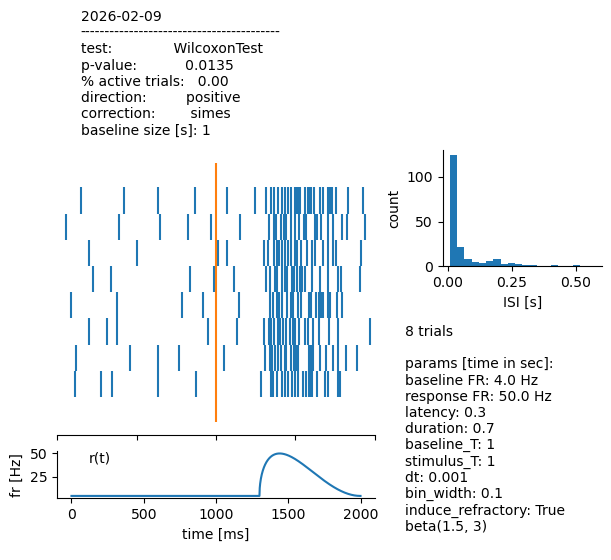

In [329]:

baseline_fr = 4
response_fr = 50
#response_fr = response_curve(baseline_fr, 2, 10) 
latency = 0.3
duration = 0.7
dt = 0.001
baseline_T = 1
stimulus_T = 1
a = 1.5
b = 3

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 8

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    a = a,
    b = b,
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 0,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, WilcoxonTest)
print(round(detector.compute_min_pval(),5))
fig, ax = SpikeSummaryFigure(trial_activity, generator, detector, ).build()


Baseline duration: 1 s
Mean, baseline: 4.0 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 7.828947368421052 Hz
0.03711


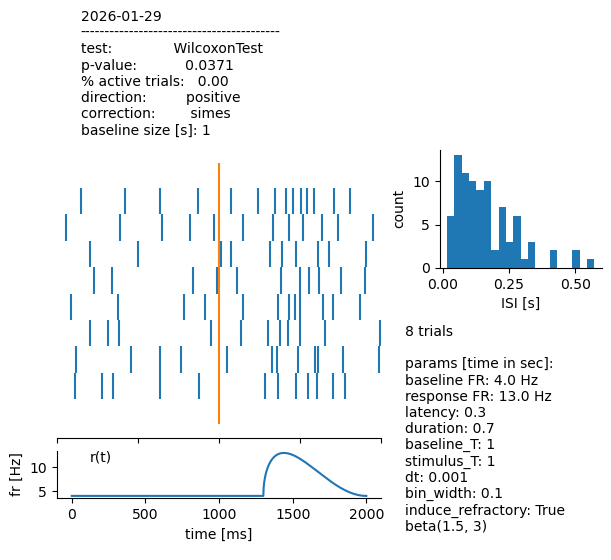

In [ ]:

def response_curve(b, slope, offset):
    return b * slope + offset

baseline_fr = 4
response_fr = response_curve(baseline_fr, 2, 5)
#response_fr = response_curve(baseline_fr, 2, 10) 
latency = 0.3
duration = 0.7
dt = 0.001
baseline_T = 1
stimulus_T = 1
a = 1.5
b = 3

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 8

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    a = a,
    b = b,
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 0,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, WilcoxonTest)
print(round(detector.compute_min_pval(),5))
fig, ax = SpikeSummaryFigure(trial_activity, generator, detector, ).build()

fig.savefig(f"plots/{baseline_fr}_{response_fr}.jpg")

In [64]:
res = {}
FRs = np.arange(0.5, 10, 0.25)
trial_list = [20, 30, 40, 50, 60, 70, 80, 85, 90, 100]

for fr in FRs:
    baseline_fr = fr
    response_fr = fr
    latency = 0.3
    duration = 0.7
    dt = 0.001
    baseline_T = 1
    stimulus_T = 1
    a = 1.5
    b = 3

    total_bins = int((baseline_T + stimulus_T) / dt)

    induce_refractory_period = True

    pval_collection = []

    for n_trials in trial_list:
        

        generator = PoissonSpikeGenerator(
            baseline_fr=baseline_fr,
            response_fr=response_fr,
            latency=latency,
            duration=duration,
            baseline_T=baseline_T,
            stimulus_T=stimulus_T,
            dt=dt,
            induce_refractory_period=induce_refractory_period,
            a = a,
            b = b,
        )

        trial_activity = generator.generate(n_trials)

        cfg_response_dict = {
            "trial_activity": trial_activity,
            "baseline_T": baseline_T,
            "stimulus_T": stimulus_T,
            "stimulus_onset": baseline_T,
            "bin_width": 0.1,
            "dt": dt,
            "direction": "positive",
            "proportion_active": 1/3,
            "multiple_correction": "simes",
            "interleave_response_bins": True,
            "smooth_response_bins": False,
            "debug": True,
        }

        cfg_response = ResponseConfig(**cfg_response_dict)
        data_response = make_response_data(cfg_response)

        detector = ResponseDetector(data_response, WilcoxonTest)
        print(round(detector.compute_min_pval(),5))
        pval_collection.append(detector.compute_min_pval())
    res[fr] = pval_collection

Baseline duration: 1 s
Mean, baseline: 0.65 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 0.3157894736842105 Hz
6 active trials out of 20 trials (30.0%).
1.0
6 active trials out of 20 trials (30.0%).
Baseline duration: 1 s
Mean, baseline: 0.6666666666666666 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 0.3157894736842105 Hz
9 active trials out of 30 trials (30.0%).
1.0
9 active trials out of 30 trials (30.0%).
Baseline duration: 1 s
Mean, baseline: 0.6 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 0.32894736842105265 Hz
13 active trials out of 40 trials (32.5%).
1.0
13 active trials out of 40 trials (32.5%).
Baseline duration: 1 s
Mean, baseline: 0.64 Hz
Response duration, edge-corrected: 1.0000000000000009 s
Mean, response: 0.3263157894736842 Hz
16 active trials out of 50 trials (32.0%).
1.0
16 active trials out of 50 trials (32.0%).
Baseline duration: 1 s
Mean, baseline: 0.6 Hz
Response duration, e

AssertionError: Binned stimulus spikes (interleaved period) do not match number of total stimulus spikes.

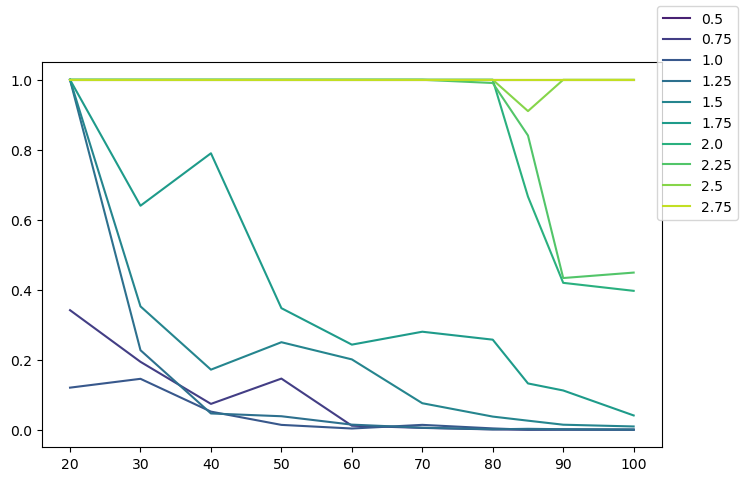

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette("viridis", n_colors=len(res))

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for color, fr in zip(palette, res.keys()):
    y = res[fr]
    ax.plot(trial_list, y, color=color, label=fr)
fig.legend()
plt.show()

In [ ]:
baseline_fr = 0.5

e = 3
gain_high = 50
b = (gain_high - e) 
y = 3
x = baseline_fr

gain = (1/y)**x * b  + e
response_fr = round(baseline_fr * gain,3)

latency = 0.3
duration = 0.5
dt = 0.001
baseline_T = 1
stimulus_T = 1
a = 1.
b = 1.75

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 10

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    a = a,
    b = b,
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)


detector = ResponseDetector(data_response, WilcoxonTest)

SpikeSummaryFigure(trial_activity, generator, detector, ).build()